In [44]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [45]:
df = pd.read_csv("heart.csv")

In [46]:
df

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0
...,...,...,...,...,...,...,...,...,...,...,...,...
913,45,M,TA,110,264,0,Normal,132,N,1.2,Flat,1
914,68,M,ASY,144,193,1,Normal,141,N,3.4,Flat,1
915,57,M,ASY,130,131,0,Normal,115,Y,1.2,Flat,1
916,57,F,ATA,130,236,0,LVH,174,N,0.0,Flat,1


In [47]:


df.shape

(918, 12)

In [48]:
df.describe()

,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,HeartDisease
count,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000
mean,53.510893,132.396514,198.799564,0.233115,136.809368,0.887364,0.553377
std,9.432617,18.514154,109.384145,0.423046,25.460334,1.066570,0.497414
min,28.000000,0.000000,0.000000,0.000000,60.000000,-2.600000,0.000000
25%,47.000000,120.000000,173.250000,0.000000,120.000000,0.000000,0.000000
50%,54.000000,130.000000,223.000000,0.000000,138.000000,0.600000,1.000000
75%,60.000000,140.000000,267.000000,0.000000,156.000000,1.500000,1.000000
max,77.000000,200.000000,603.000000,1.000000,202.000000,6.200000,1.000000


In [49]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 918 entries, 0 to 917
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Age             918 non-null    int64  
 1   Sex             918 non-null    object 
 2   ChestPainType   918 non-null    object 
 3   RestingBP       918 non-null    int64  
 4   Cholesterol     918 non-null    int64  
 5   FastingBS       918 non-null    int64  
 6   RestingECG      918 non-null    object 
 7   MaxHR           918 non-null    int64  
 8   ExerciseAngina  918 non-null    object 
 9   Oldpeak         918 non-null    float64
 10  ST_Slope        918 non-null    object 
 11  HeartDisease    918 non-null    int64  
dtypes: float64(1), int64(6), object(5)
memory usage: 86.2+ KB


In [50]:
df.isnull().sum()

Age               0
Sex               0
ChestPainType     0
RestingBP         0
Cholesterol       0
FastingBS         0
RestingECG        0
MaxHR             0
ExerciseAngina    0
Oldpeak           0
ST_Slope          0
HeartDisease      0
dtype: int64

In [51]:
df.drop_duplicates(inplace=True)

In [52]:
df.shape

(918, 12)

In [53]:
df['HeartDisease'].value_counts()


HeartDisease
1    508
0    410
Name: count, dtype: int64

<Axes: xlabel='HeartDisease', ylabel='count'>

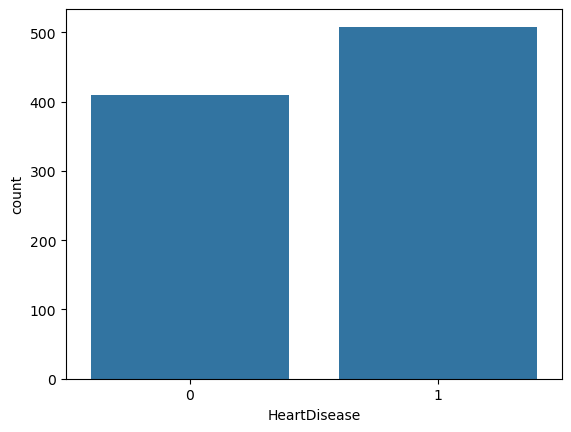

In [54]:
sns.countplot(x= df['HeartDisease'])

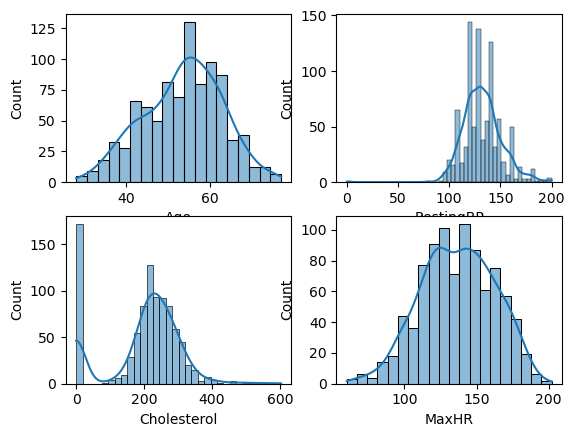

In [55]:
def plot_distribution(var , num):
    plt.subplot(2, 2 , num)
    sns.histplot(x = df[var], kde = True)
num =1 
list1 = ["Age", "RestingBP" , "Cholesterol", "MaxHR"]    
for i in list1:
    plot_distribution(i,num)
    num+=1




In [56]:
ch_mean = df.loc[df['Cholesterol']!= 0 , 'Cholesterol'].mean()

In [57]:
df['Cholesterol']= df['Cholesterol'].replace(0 , ch_mean)
df["Cholesterol"]= df['Cholesterol'].round(2)

In [58]:
rp_mean = df.loc[df['RestingBP']!= 0 , 'RestingBP'].mean()

In [59]:
df['RestingBP']= df['RestingBP'].replace(0 , rp_mean)
df["RestingBP"] = df['RestingBP'].round(2)

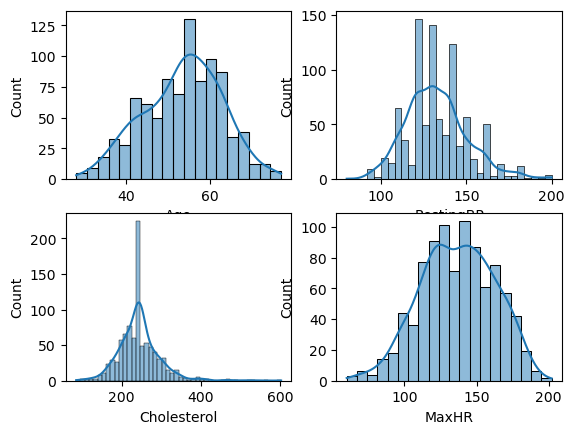

In [60]:
def plot_distribution(var , num):
    plt.subplot(2, 2 , num)
    sns.histplot(x = df[var], kde = True)
num =1 
list1 = ["Age", "RestingBP" , "Cholesterol", "MaxHR"]    
for i in list1:
    plot_distribution(i,num)
    num+=1

<Axes: xlabel='Sex', ylabel='count'>

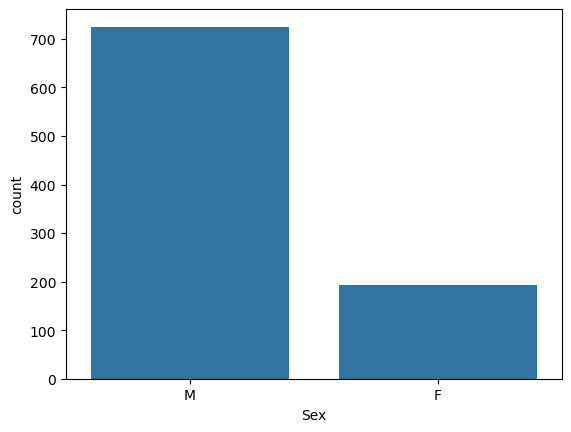

In [61]:
sns.countplot(x = df['Sex'])

<Axes: xlabel='ChestPainType', ylabel='count'>

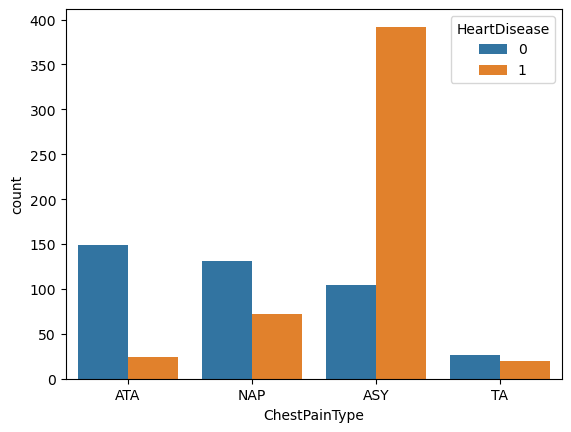

In [62]:
sns.countplot(x = df["ChestPainType"] , hue = df['HeartDisease'])

<Axes: xlabel='ChestPainType', ylabel='count'>

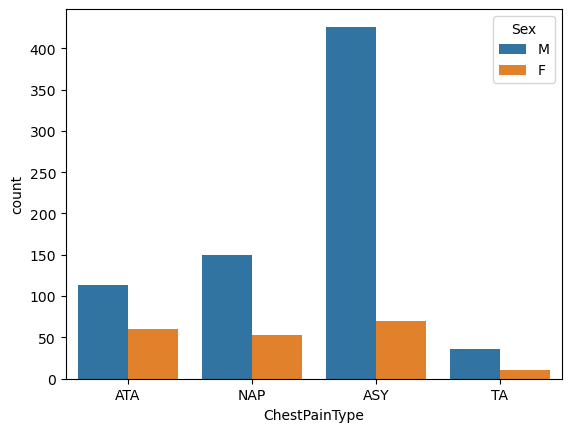

In [63]:
sns.countplot(x = df['ChestPainType'] , hue = df["Sex"])

<Axes: xlabel='HeartDisease', ylabel='Cholesterol'>

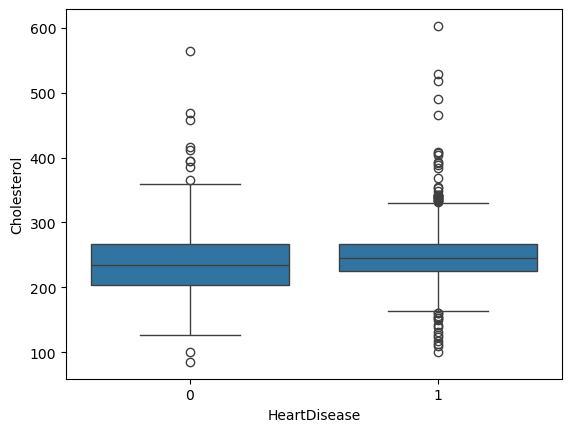

In [64]:
sns.boxplot(x = df["HeartDisease"] , y = df["Cholesterol"])

<Axes: >

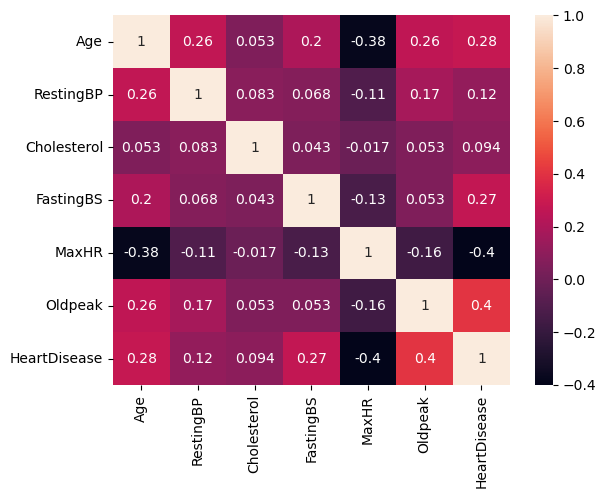

In [65]:
sns.heatmap(df.corr(numeric_only=True) , annot= True)

# Data Preprocessing 

In [66]:
df_encode = pd.get_dummies(df , drop_first= True )

In [67]:
df_encode.head()

,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,HeartDisease,Sex_M,ChestPainType_ATA,ChestPainType_NAP,ChestPainType_TA,RestingECG_Normal,RestingECG_ST,ExerciseAngina_Y,ST_Slope_Flat,ST_Slope_Up
0,40,140.0,289.0,0,172,0.0,0,True,True,False,False,True,False,False,False,True
1,49,160.0,180.0,0,156,1.0,1,False,False,True,False,True,False,False,True,False
2,37,130.0,283.0,0,98,0.0,0,True,True,False,False,False,True,False,False,True
3,48,138.0,214.0,0,108,1.5,1,False,False,False,False,True,False,True,True,False
4,54,150.0,195.0,0,122,0.0,0,True,False,True,False,True,False,False,False,True


In [68]:
df_encode = df_encode.astype(int)

In [69]:
df_encode

,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,HeartDisease,Sex_M,ChestPainType_ATA,ChestPainType_NAP,ChestPainType_TA,RestingECG_Normal,RestingECG_ST,ExerciseAngina_Y,ST_Slope_Flat,ST_Slope_Up
0,40,140,289,0,172,0,0,1,1,0,0,1,0,0,0,1
1,49,160,180,0,156,1,1,0,0,1,0,1,0,0,1,0
2,37,130,283,0,98,0,0,1,1,0,0,0,1,0,0,1
3,48,138,214,0,108,1,1,0,0,0,0,1,0,1,1,0
4,54,150,195,0,122,0,0,1,0,1,0,1,0,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
913,45,110,264,0,132,1,1,1,0,0,1,1,0,0,1,0
914,68,144,193,1,141,3,1,1,0,0,0,1,0,0,1,0
915,57,130,131,0,115,1,1,1,0,0,0,1,0,1,1,0
916,57,130,236,0,174,0,1,0,1,0,0,0,0,0,1,0


In [70]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, f1_score, classification_report
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier

In [71]:
X = df_encode.drop("HeartDisease" , axis = 1)
y = df_encode["HeartDisease"]

In [72]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [73]:
scaler = StandardScaler()
X_train_scale = scaler.fit_transform(X_train)
X_test_scale = scaler.fit_transform(X_test)

In [74]:
models = {
    "logistic_Regression" : LogisticRegression(),
    "naive_bayes" : GaussianNB(),
    "decisionTree" : DecisionTreeClassifier(),
    "svm" : SVC(),
    "knn" : KNeighborsClassifier(),

}

In [75]:
result = [] 

In [82]:
for name , model in models.items():
    model.fit(X_train_scale , y_train)
    y_pred = model.predict(X_test_scale)
    acc = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test , y_pred)
    result.append({
        'Model' : name, 
         "accuary" : round(acc , 4),
        "f1score" : round(f1 , 4)
        
    })

In [83]:
result

[{'Model': 'logistic_Regression', 'accuary': 0.8696, 'f1score': 0.8857},
 {'Model': 'naive_bayes', 'accuary': 0.8533, 'f1score': 0.8683},
 {'Model': 'decisionTree', 'accuary': 0.75, 'f1score': 0.7723},
 {'Model': 'svm', 'accuary': 0.8478, 'f1score': 0.8679},
 {'Model': 'knn', 'accuary': 0.8641, 'f1score': 0.8815}]

In [88]:
import joblib
joblib.dump(models['knn'], 'knn_heart.pkl' )
joblib.dump(scaler,'scaler.pkl')
joblib.dump(X.columns.tolist() , 'columns.pkl')

['columns.pkl']